# 07. Datos personales (últimos 5 años)

**Fuente:** `data/raw/datos_personales_ultimos_5anios.csv`  
**Salida:** `data/processed/datos_personales_ultimos_5anios.csv`

Datos demograficos base del personal (estado civil, fecha de nacimiento, sexo, origen). Se deriva la edad como variable simple para el perfil.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('datos_personales_ultimos_5anios.csv', low_memory=False)
df.head()

Leido datos_personales_ultimos_5anios.csv con encoding=utf-8-sig -> 3195 filas, 7 columnas


,IDPERSONA,ESTADOCIVIL,FECHANACIMIENTO,SEXO,PAISORIGEN,PROVINCIAORIGEN,CANTONORIGEN
0,452,C,1932-06-25,M,ECUADOR,GUAYAS,GUAYAQUIL
1,970,C,1942-04-17,M,ESTADOS UNIDOS,CALIFORNIA,SANTA CLARA
2,492,V,1942-05-15,M,ECUADOR,LOS RIOS,BABAHOYO
3,256,C,1942-07-29,M,ECUADOR,GUAYAS,GUAYAQUIL
4,98983,C,1944-11-03,M,ECUADOR,EL ORO,ARENILLAS


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'datos_personales_ultimos_5anios')

--- Resumen datos_personales_ultimos_5anios ---
Dimensiones: 3195 filas x 7 columnas
Filas duplicadas: 0
Columnas con nulos (%):
CANTONORIGEN       1.5
PROVINCIAORIGEN    1.2
ESTADOCIVIL        0.0
FECHANACIMIENTO    0.0
dtype: float64


In [4]:
df.dtypes

IDPERSONA          int64
ESTADOCIVIL          str
FECHANACIMIENTO      str
SEXO                 str
PAISORIGEN           str
PROVINCIAORIGEN      str
CANTONORIGEN         str
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_fechas(df, ['FECHANACIMIENTO'])
df = pc.castear_enteros(df, ['IDPERSONA'])

## 6. Variable derivada: edad

In [7]:
hoy = pd.Timestamp.today().normalize()
df['EDAD'] = ((hoy - df['FECHANACIMIENTO']).dt.days // 365.25).astype('Int64')
df['EDAD'].describe()

count       3168.0
mean     41.568813
std      11.876708
min           20.0
25%           32.0
50%           40.0
75%           49.0
max           76.0
Name: EDAD, dtype: Float64

## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Distribución de edad** del personal (variable derivada EDAD).

<Axes: title={'center': 'Distribución de edad del personal'}>

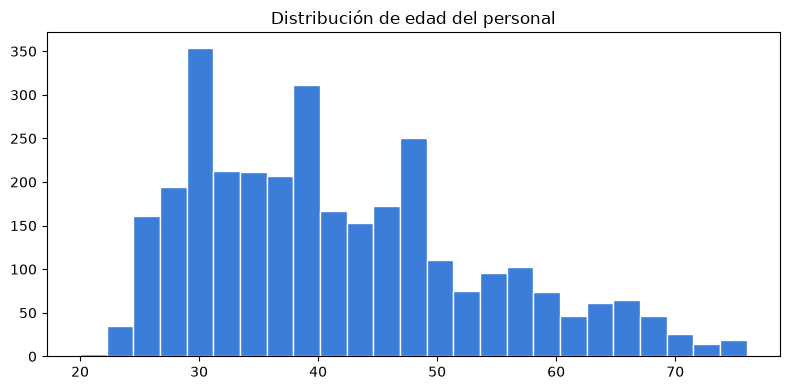

In [9]:
pc.grafico_histograma(df['EDAD'], 'Distribución de edad del personal', bins=25, recorte_percentil=None)

**Distribución por sexo**.

<Axes: title={'center': 'Distribución por sexo'}, xlabel='SEXO'>

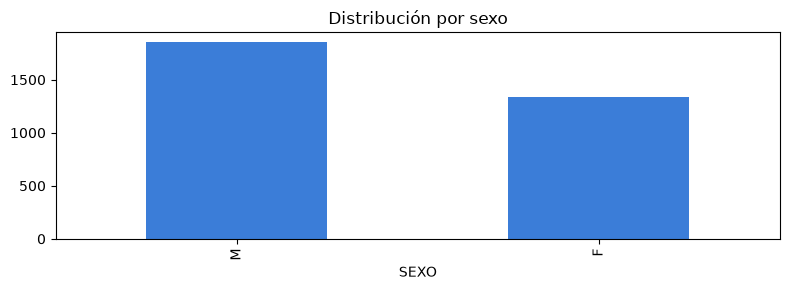

In [10]:
pc.grafico_barras(df['SEXO'], 'Distribución por sexo', horizontal=False)

**Distribución por estado civil**.

<Axes: title={'center': 'Distribución por estado civil'}, xlabel='ESTADOCIVIL'>

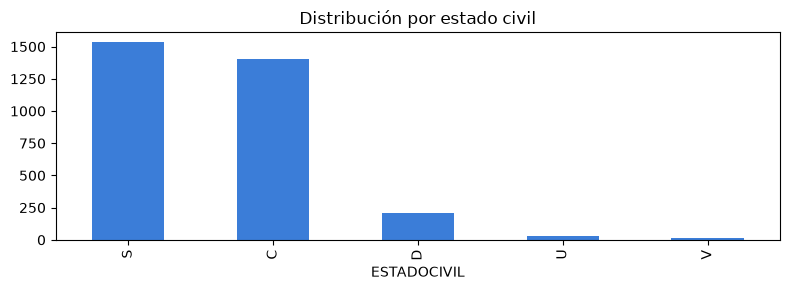

In [11]:
pc.grafico_barras(df['ESTADOCIVIL'], 'Distribución por estado civil', horizontal=False)

**Provincias de origen más frecuentes**.

<Axes: title={'center': 'Top 10 provincias de origen'}, ylabel='PROVINCIAORIGEN'>

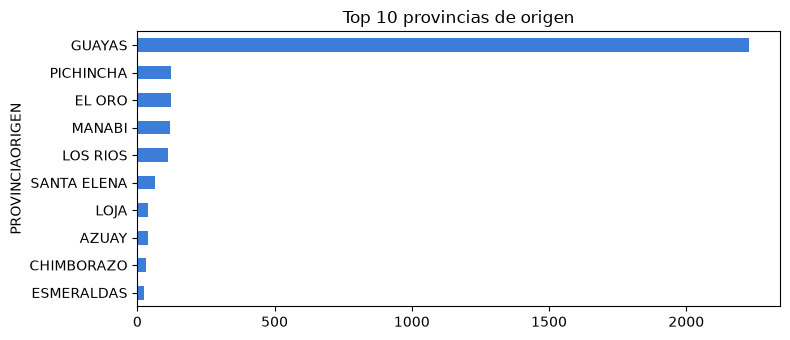

In [12]:
pc.grafico_barras(df['PROVINCIAORIGEN'], 'Top 10 provincias de origen', top=10)

## 7. Verificación final

In [13]:
pc.resumen(df, 'datos_personales_ultimos_5anios (procesado)')
df.head()

--- Resumen datos_personales_ultimos_5anios (procesado) ---
Dimensiones: 3195 filas x 8 columnas
Filas duplicadas: 0
Columnas con nulos (%):
CANTONORIGEN       1.5
PROVINCIAORIGEN    1.2
FECHANACIMIENTO    0.8
EDAD               0.8
ESTADOCIVIL        0.0
dtype: float64


,IDPERSONA,ESTADOCIVIL,FECHANACIMIENTO,SEXO,PAISORIGEN,PROVINCIAORIGEN,CANTONORIGEN,EDAD
0,452,C,NaT,M,ECUADOR,GUAYAS,GUAYAQUIL,<NA>
1,970,C,NaT,M,ESTADOS UNIDOS,CALIFORNIA,SANTA CLARA,<NA>
2,492,V,NaT,M,ECUADOR,LOS RIOS,BABAHOYO,<NA>
3,256,C,NaT,M,ECUADOR,GUAYAS,GUAYAQUIL,<NA>
4,98983,C,NaT,M,ECUADOR,EL ORO,ARENILLAS,<NA>


## Exclusión de personas identificadas en defunción

Las personas listadas en `data/raw/defunciones_identificadas.txt` no se consideran en **ningún** análisis: trayectoria, evidencias, clustering ni embeddings (decisión del usuario, 2026-09-28, DEC-030). Se quitan aquí, al definir la población, y todos los notebooks posteriores las heredan. Quedan registradas con su motivo en `data/processed/personas_excluidas.csv`.

In [14]:
n_antes = len(df)
df, personas_excluidas = pc.excluir_defunciones(df)
print(f'Identificadas en defuncion: {len(pc.cargar_ids_defunciones())} | en la poblacion: {len(personas_excluidas)}')
print(f'Poblacion: {n_antes} -> {len(df)}')
pc.guardar_procesado(personas_excluidas, 'personas_excluidas.csv')

Identificadas en defuncion: 33 | en la poblacion: 24
Poblacion: 3195 -> 3171
Guardado: C:\Users\carlo\Documents\MCD2025\Tesis MCD IA\proyectotesis\Proyecto_Tesis\data\processed\personas_excluidas.csv (24 filas x 2 columnas)


WindowsPath('C:/Users/carlo/Documents/MCD2025/Tesis MCD IA/proyectotesis/Proyecto_Tesis/data/processed/personas_excluidas.csv')

## 8. Guardado en data/processed

In [15]:
pc.guardar_procesado(df, 'datos_personales_ultimos_5anios.csv')

Guardado: C:\Users\carlo\Documents\MCD2025\Tesis MCD IA\proyectotesis\Proyecto_Tesis\data\processed\datos_personales_ultimos_5anios.csv (3171 filas x 8 columnas)


WindowsPath('C:/Users/carlo/Documents/MCD2025/Tesis MCD IA/proyectotesis/Proyecto_Tesis/data/processed/datos_personales_ultimos_5anios.csv')